In [2]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
import numpy as np
import pandas as pd
from thinkdsp import TriangleSignal, decorate, SquareSignal, SawtoothSignal, CubicSignal, PI2, zero_pad, Wave, Spectrum
import matplotlib.pyplot as plt

Упражнение 9.1

In [4]:
df = pd.read_csv('FB_2.csv', header=0, parse_dates=[0])
prices = df['Close'].values

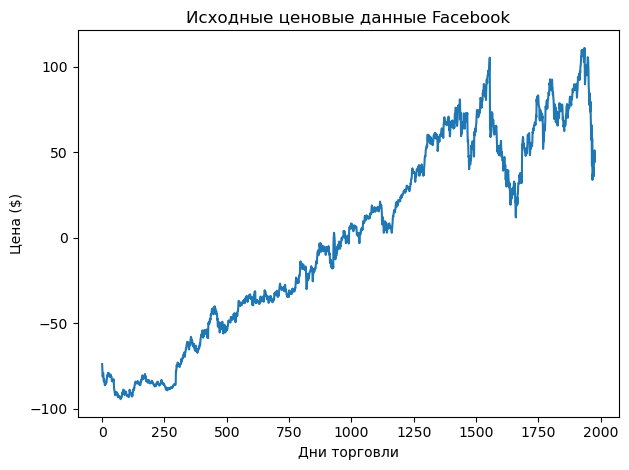

In [5]:
in_wave = Wave(prices, framerate=1)
in_wave.unbias()
in_wave.plot()
plt.title("Исходные ценовые данные Facebook")
decorate(xlabel='Дни торговли', ylabel='Цена ($)')

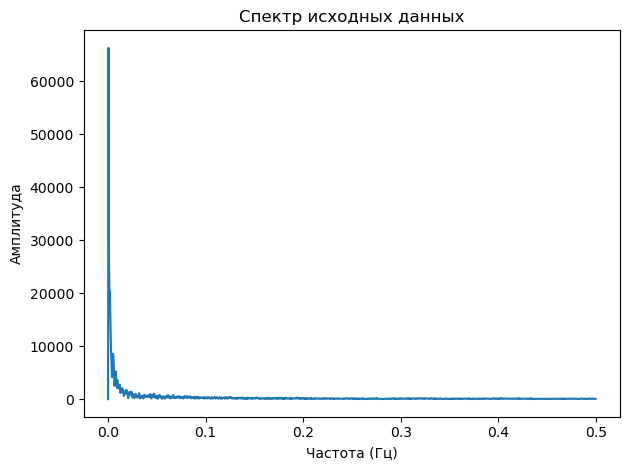

In [6]:
in_spectrum = in_wave.make_spectrum()
in_spectrum.plot()
plt.title("Спектр исходных данных")
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

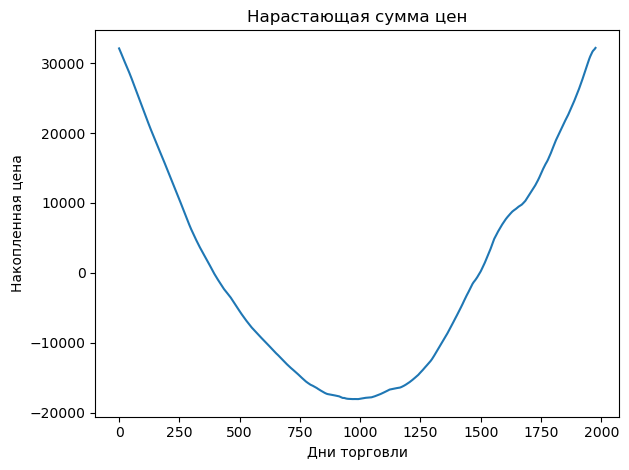

In [7]:
out_wave = in_wave.cumsum()
out_wave.unbias()
out_wave.plot()
plt.title("Нарастающая сумма цен")
decorate(xlabel='Дни торговли', ylabel='Накопленная цена')

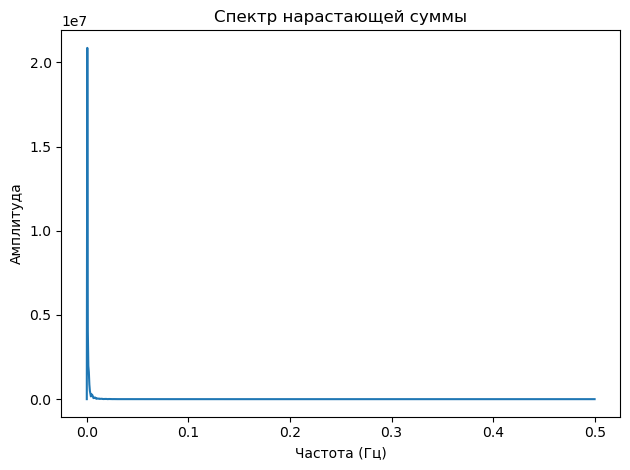

In [8]:
out_spectrum = out_wave.make_spectrum()
out_spectrum.plot()
plt.title("Спектр нарастающей суммы")
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

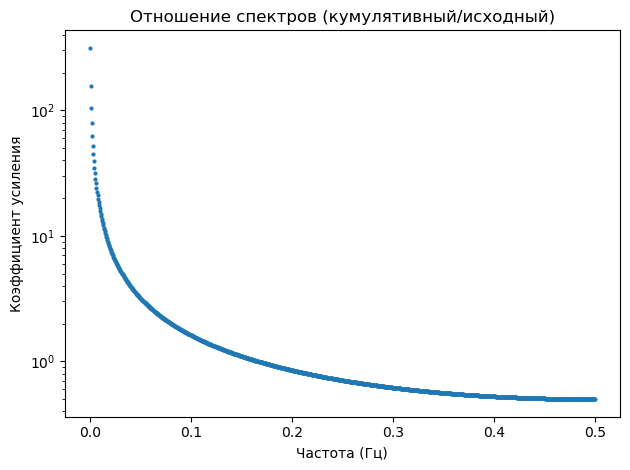

In [9]:
ratio_spectrum = out_spectrum.ratio(in_spectrum, thresh=1)
ratio_spectrum.plot(marker='.', ms=4, ls='')
plt.title("Отношение спектров (кумулятивный/исходный)")
decorate(xlabel='Частота (Гц)',
         ylabel='Коэффициент усиления',
         yscale='log')

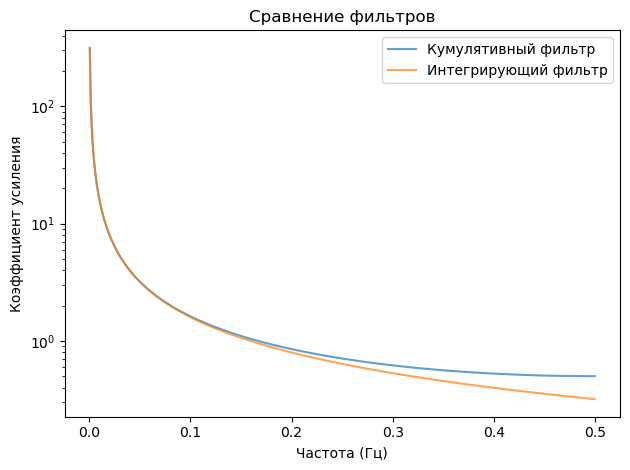

In [10]:
diff_window = np.array([1.0, -1.0])
padded = zero_pad(diff_window, len(in_wave))
diff_wave = Wave(padded, framerate=in_wave.framerate)
diff_filter = diff_wave.make_spectrum()

cumsum_filter = diff_filter.copy()
cumsum_filter.hs[1:] = 1 / cumsum_filter.hs[1:]
cumsum_filter.hs[0] = np.inf

integ_filter = cumsum_filter.copy()
integ_filter.hs[1:] = integ_filter.framerate / (PI2 * 1j * integ_filter.fs[1:])
integ_filter.hs[0] = np.inf

cumsum_filter.plot(label='Кумулятивный фильтр', alpha=0.7)
integ_filter.plot(label='Интегрирующий фильтр', alpha=0.7)
plt.title("Сравнение фильтров")
decorate(xlabel='Частота (Гц)',
         ylabel='Коэффициент усиления',
         yscale='log')
plt.legend()

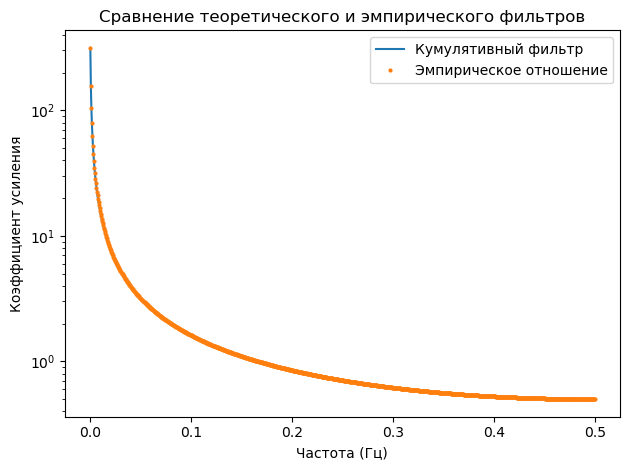

In [11]:
cumsum_filter.plot(label='Кумулятивный фильтр')
ratio_spectrum.plot(label='Эмпирическое отношение', marker='.', ms=4, ls='')
plt.title("Сравнение теоретического и эмпирического фильтров")
decorate(xlabel='Частота (Гц)',
         ylabel='Коэффициент усиления',
         yscale='log')
plt.legend()

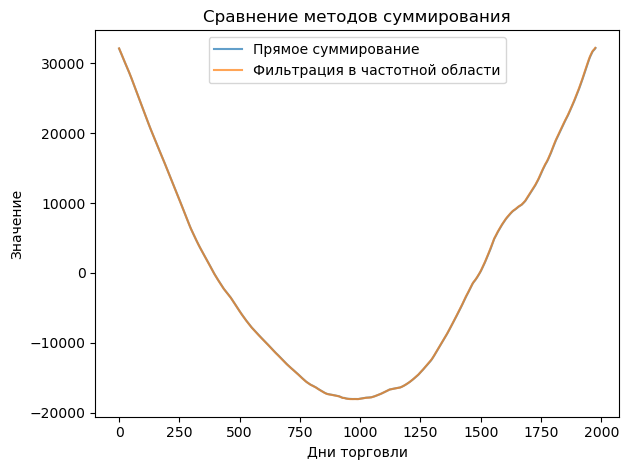

In [12]:
out_wave.plot(label='Прямое суммирование', alpha=0.7)
cumsum_filter.hs[0] = 0
out_wave2 = (in_spectrum * cumsum_filter).make_wave()
out_wave2.plot(label='Фильтрация в частотной области', alpha=0.7)
plt.title("Сравнение методов суммирования")
decorate(xlabel='Дни торговли', ylabel='Значение')
plt.legend()

Упражнение 9.2

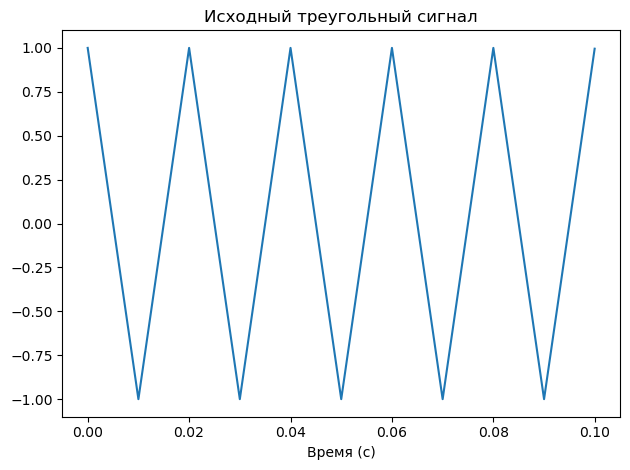

In [14]:
tri_signal = TriangleSignal(freq=50)
tri_wave = tri_signal.make_wave(duration=0.1, framerate=44100)
tri_wave.plot()
plt.title("Исходный треугольный сигнал")
decorate(xlabel='Время (с)')
plt.show()

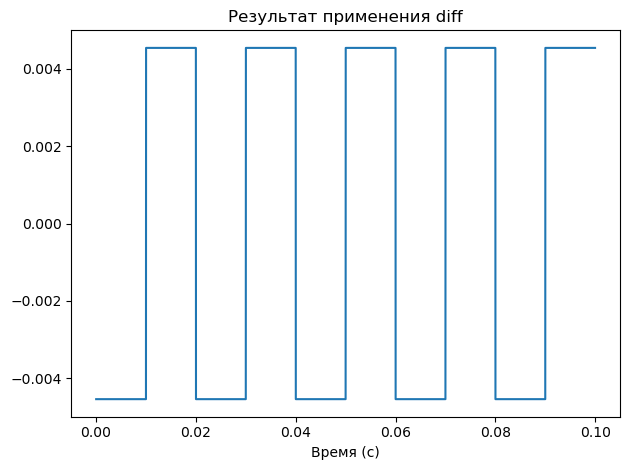

In [15]:
diff_wave = tri_wave.diff()
diff_wave.plot()
plt.title("Результат применения diff")
decorate(xlabel='Время (с)')
plt.show()

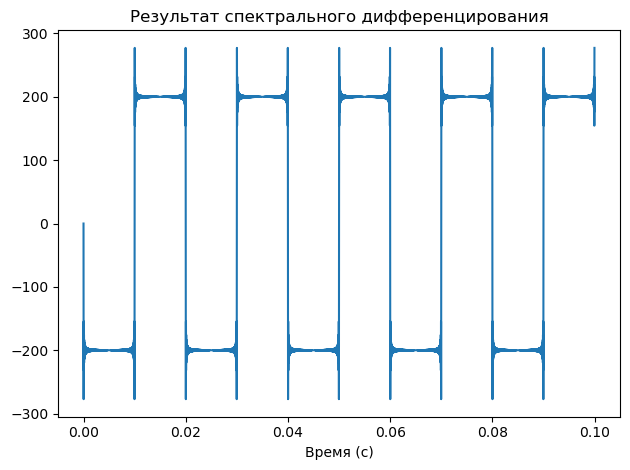

In [16]:
spectrum = tri_wave.make_spectrum().differentiate().make_wave()
spectrum.plot()
plt.title("Результат спектрального дифференцирования")
decorate(xlabel='Время (с)')

Упражнение 9.3

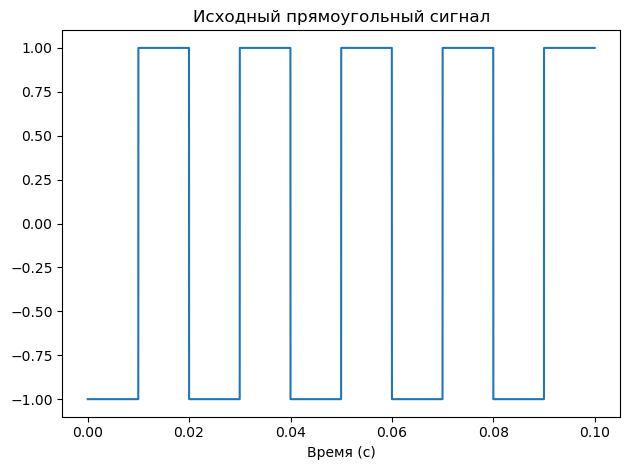

In [18]:
square_signal = SquareSignal(freq=50)
square_wave = square_signal.make_wave(duration=0.1, framerate=44100)

square_wave.plot()
plt.title("Исходный прямоугольный сигнал")
decorate(xlabel='Время (с)')
plt.show()

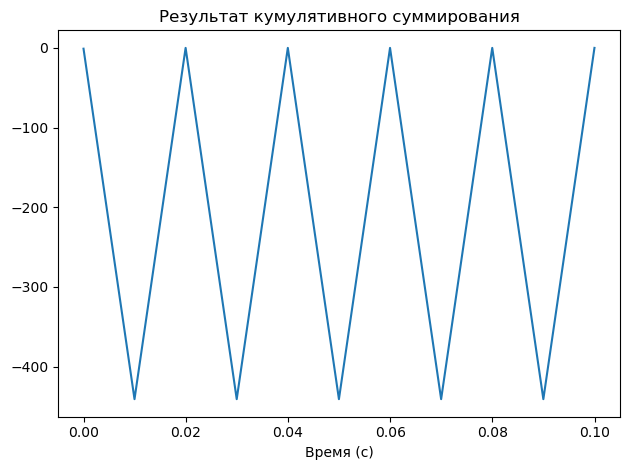

In [19]:
cumsum_wave = square_wave.cumsum()

cumsum_wave.plot()
plt.title("Результат кумулятивного суммирования")
decorate(xlabel='Время (с)')
plt.show()

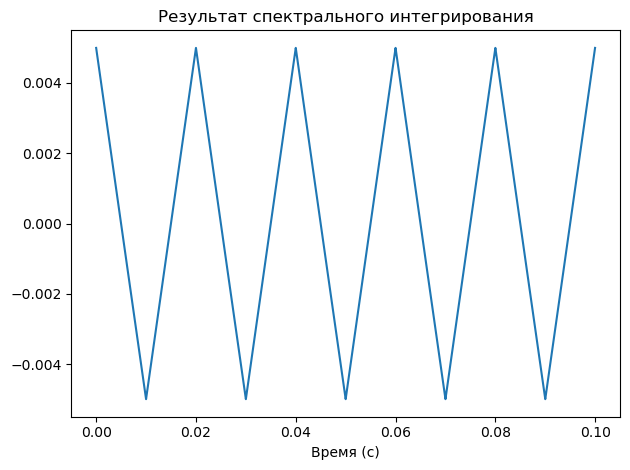

In [20]:
spec = square_wave.make_spectrum().integrate()
spec.hs[0] = 0
integ_wave_spectral = spec.make_wave()

integ_wave_spectral.plot()
plt.title("Результат спектрального интегрирования")
decorate(xlabel='Время (с)')

In [21]:
cumsum_wave.unbias()
cumsum_wave.normalize()

In [22]:
integ_wave_spectral.normalize()

In [23]:
cumsum_wave.max_diff(integ_wave_spectral)

0.0045351473922902175

Упражнение 9.4

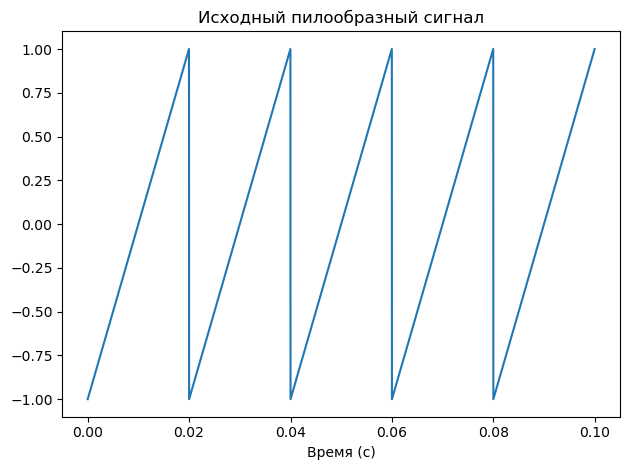

In [25]:
saw_signal = SawtoothSignal(freq=50)
saw_wave = saw_signal.make_wave(duration=0.1, framerate=44100)

saw_wave.plot()
plt.title("Исходный пилообразный сигнал")
decorate(xlabel='Время (с)')
plt.show()

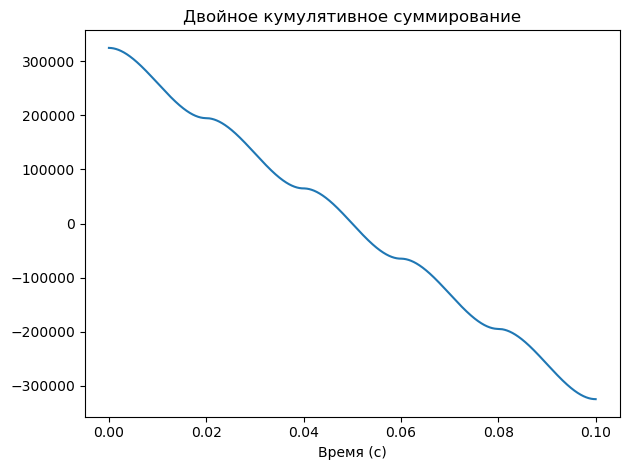

In [26]:
double_cumsum = saw_wave.cumsum().cumsum()
double_cumsum.unbias()

double_cumsum.plot()
plt.title("Двойное кумулятивное суммирование")
decorate(xlabel='Время (с)')
plt.show()

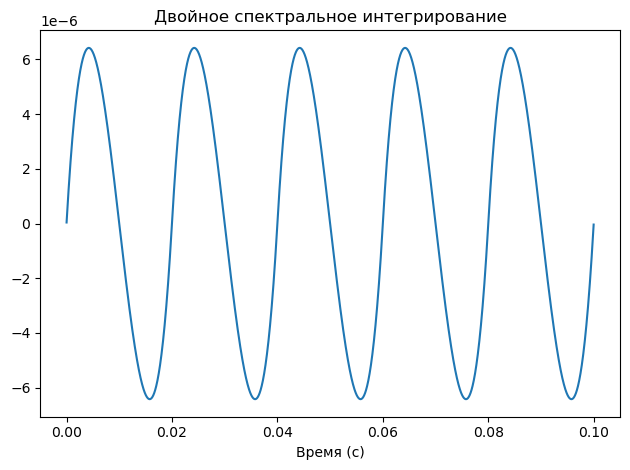

In [27]:
spec = saw_wave.make_spectrum().integrate().integrate()
spec.hs[0] = 0
double_integ_wave = spec.make_wave()

double_integ_wave.plot()
plt.title("Двойное спектральное интегрирование")
decorate(xlabel='Время (с)')
plt.show()

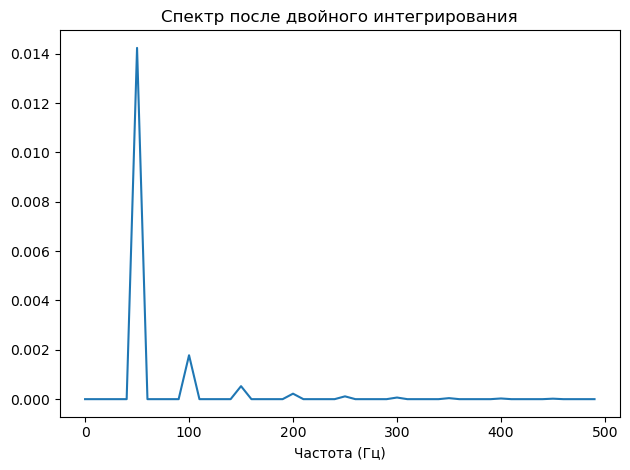

In [28]:
double_integ_wave.make_spectrum().plot(high=500)
plt.title("Спектр после двойного интегрирования")
decorate(xlabel='Частота (Гц)')
plt.show()

Упражнение 9.5

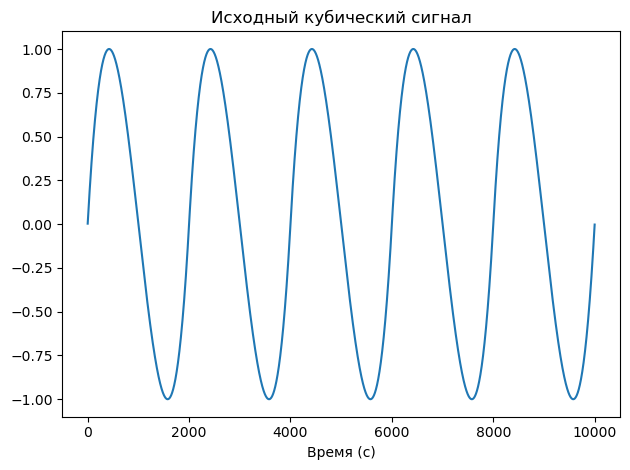

In [30]:
cubic_signal = CubicSignal(freq=0.0005)
cubic_wave = cubic_signal.make_wave(duration=10000, framerate=1)

cubic_wave.plot()
plt.title("Исходный кубический сигнал")
decorate(xlabel='Время (с)')
plt.show()

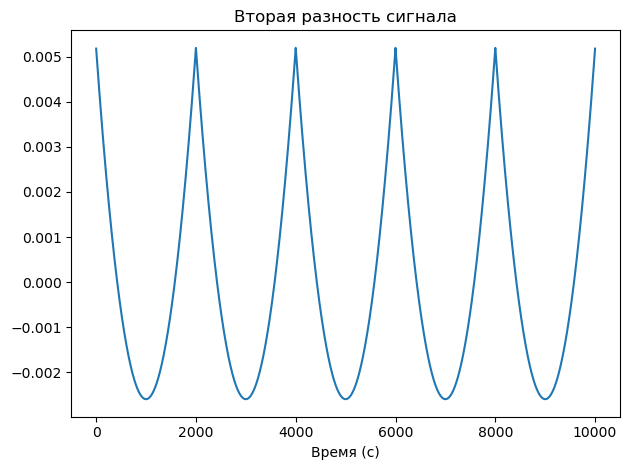

In [31]:
second_diff = cubic_wave.diff()

second_diff.plot()
plt.title("Вторая разность сигнала")
decorate(xlabel='Время (с)')
plt.show()

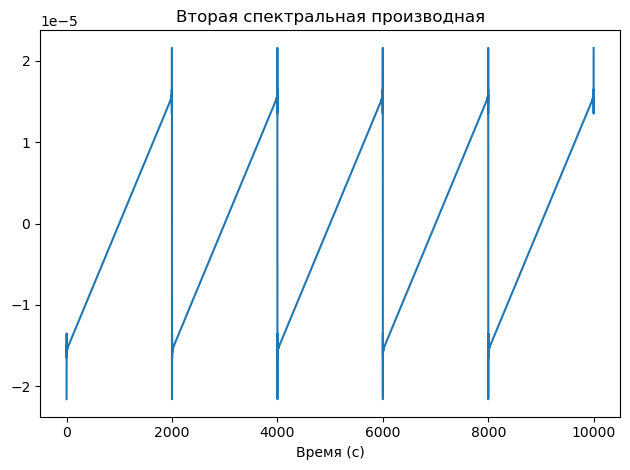

In [32]:
spec = cubic_wave.make_spectrum().differentiate().differentiate()
second_deriv_wave = spec.make_wave()

second_deriv_wave.plot()
plt.title("Вторая спектральная производная")
decorate(xlabel='Время (с)')
plt.show()

In [33]:
diff_filter_coeffs = np.array([-1.0, 2.0, -1.0])
padded_coeffs = zero_pad(diff_filter_coeffs, len(cubic_wave))
diff_filter_wave = Wave(padded_coeffs, framerate=cubic_wave.framerate)
diff_filter_spec = diff_filter_wave.make_spectrum()

deriv_filter_spec = cubic_wave.make_spectrum()
deriv_filter_spec.hs = (PI2 * 1j * deriv_filter_spec.fs)**2

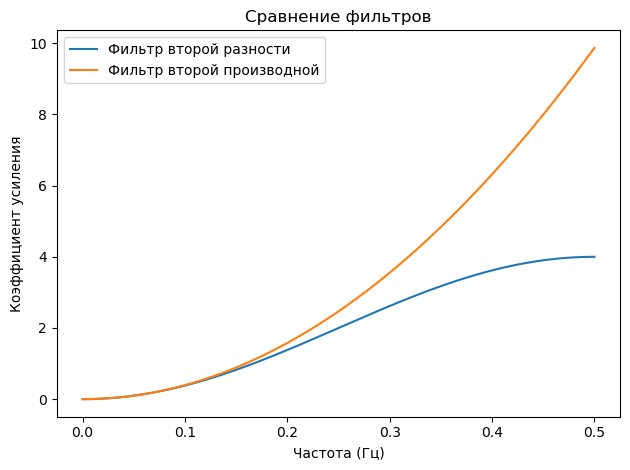

In [34]:
diff_filter_spec.plot(label='Фильтр второй разности')
deriv_filter_spec.plot(label='Фильтр второй производной')
plt.title("Сравнение фильтров")
decorate(xlabel='Частота (Гц)', ylabel='Коэффициент усиления')
plt.legend()
plt.show()